# SDT Model Compilation and Testing Workflow

This notebook provides step-by-step instructions for compiling and testing the SDT (Signal Detection Theory) JAGS module.


## Prerequisites

Ensure you have the required dependencies installed:
- JAGS 4.3.0+
- ONNX Runtime 1.23.2+ (Linux x64)
- py2jags 0.1.0+
- Python 3.11+ with scikit-learn


In [1]:
# Naming from metadata
from jnnx import JNNXPackage
_pkg = JNNXPackage('/home/jovyan/project/models/sdt.jnnx')
MODULE_NAME = _pkg.metadata['module_name']
FUNCTION_NAME = _pkg.metadata['function_name']
print('Using module/function:', MODULE_NAME, FUNCTION_NAME)


Using module/function: sdt_emulator sdt_emulator


## Step 1: Generate Module Code


In [2]:
from jnnx import JNNXPackage, JAGSModule

# Generate module code using Python API
pkg = JNNXPackage('/home/jovyan/project/models/sdt.jnnx')
module = JAGSModule(pkg, 'tmp/sdt.jnnx_build')
module.generate_code()
print('Module code generated in tmp/sdt.jnnx_build')


Copied external data file to tmp/sdt.jnnx_build/model.onnx.data
Module code generated in tmp/sdt.jnnx_build


In [3]:
# Ensure ONNX Runtime is available at expected path for compilation
import os, tarfile, urllib.request
from pathlib import Path

onnx_dir = Path('/home/jovyan/project/tmp/onnxruntime-linux-x64-1.23.2')
if not onnx_dir.exists():
    onnx_dir.parent.mkdir(parents=True, exist_ok=True)
    url = 'https://github.com/microsoft/onnxruntime/releases/download/v1.23.2/onnxruntime-linux-x64-1.23.2.tgz'
    tgz_path = onnx_dir.parent / 'onnxruntime-linux-x64-1.23.2.tgz'
    print('Downloading ONNX Runtime...', url)
    urllib.request.urlretrieve(url, tgz_path)
    print('Extracting...', tgz_path)
    with tarfile.open(tgz_path, 'r:gz') as tf:
        tf.extractall(path=onnx_dir.parent)
    print('ONNX Runtime ready at', onnx_dir)
else:
    print('ONNX Runtime already present at', onnx_dir)


ONNX Runtime already present at /home/jovyan/project/tmp/onnxruntime-linux-x64-1.23.2


## Step 2: Compile the Module


In [4]:
# Compile using Python API
success, msg = module.compile()
if not success:
    raise RuntimeError(msg)
print('Compilation succeeded')


Compilation succeeded


In [5]:
# Install using Python API
success, msg = module.install()
if not success:
    raise RuntimeError(msg)
print('Installation succeeded')


Installation succeeded


## Step 3: Test the Module


In [6]:
import py2jags
import onnxruntime as ort
import numpy as np

# Test SDT function using names from metadata
model_string = f'''
model {{
    result <- {FUNCTION_NAME}(0.0, 0.0)
    dummy ~ dnorm(0, 1)
}}
'''

result = py2jags.run_jags(
    model_string=model_string,
    data_dict={'n': 1},
    nchains=1, nsamples=1, nadapt=0, nburnin=0,
    monitorparams=['result'],
    modules=[MODULE_NAME],
    verbosity=0
)

print('SDT output:', [result.get_samples(f'result_{i+1}')[0] for i in range(2)])


SDT output: [0.688367, 0.999734]


/opt/conda/envs/pymc/lib/python3.11/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/conda/envs/pymc/lib/python3.11/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


## Step 4: Validate Against Python ONNX


In [7]:
import onnxruntime as ort
import numpy as np
from jnnx import JNNXPackage

# Load ONNX model via API
pkg = JNNXPackage('/home/jovyan/project/models/sdt.jnnx')
session = ort.InferenceSession(pkg.get_onnx_path())
test_input = np.array([[0.0, 0.0]], dtype=np.float32)
result = session.run(['output'], {'input': test_input})
print('Python ONNX output:', result[0][0].tolist())


Python ONNX output: [0.6883670091629028, 0.9997339248657227]


## Step 5: Compare Results


In [8]:
# Run both tests and compare
import py2jags
import onnxruntime as ort
import numpy as np

# JAGS evaluation
model_string = f'''
model {{
    result <- {FUNCTION_NAME}(0.0, 0.0)
    dummy ~ dnorm(0, 1)
}}
'''

jags_result = py2jags.run_jags(
    model_string=model_string,
    data_dict={'n': 1},
    nchains=1, nsamples=1, nadapt=0, nburnin=0,
    monitorparams=['result'],
    modules=[MODULE_NAME],
    verbosity=0
)

jags_output = [jags_result.get_samples(f'result_{i+1}')[0] for i in range(2)]

# Python ONNX evaluation via API
from jnnx import JNNXPackage
pkg = JNNXPackage('/home/jovyan/project/models/sdt.jnnx')
session = ort.InferenceSession(pkg.get_onnx_path())
test_input = np.array([[0.0, 0.0]], dtype=np.float32)
onx_result = session.run(['output'], {'input': test_input})
onnx_output = onx_result[0][0].tolist()

# Compare results
print('JAGS output:  ', jags_output)
print('Python output:', onnx_output)
print('Differences:  ', [abs(jags_output[i] - onnx_output[i]) for i in range(2)])

# Check if results match within machine precision
max_diff = max([abs(jags_output[i] - onnx_output[i]) for i in range(2)])
if max_diff < 1e-6:
    print('SUCCESS: Results match within machine precision')
else:
    print('ERROR: Results differ significantly')


JAGS output:   [0.688367, 0.999734]
Python output: [0.6883670091629028, 0.9997339248657227]
Differences:   [9.162902880888169e-09, 7.513427735528211e-08]
SUCCESS: Results match within machine precision


Evaluating JAGS model...
Evaluating Python ONNX model...
Creating plots...


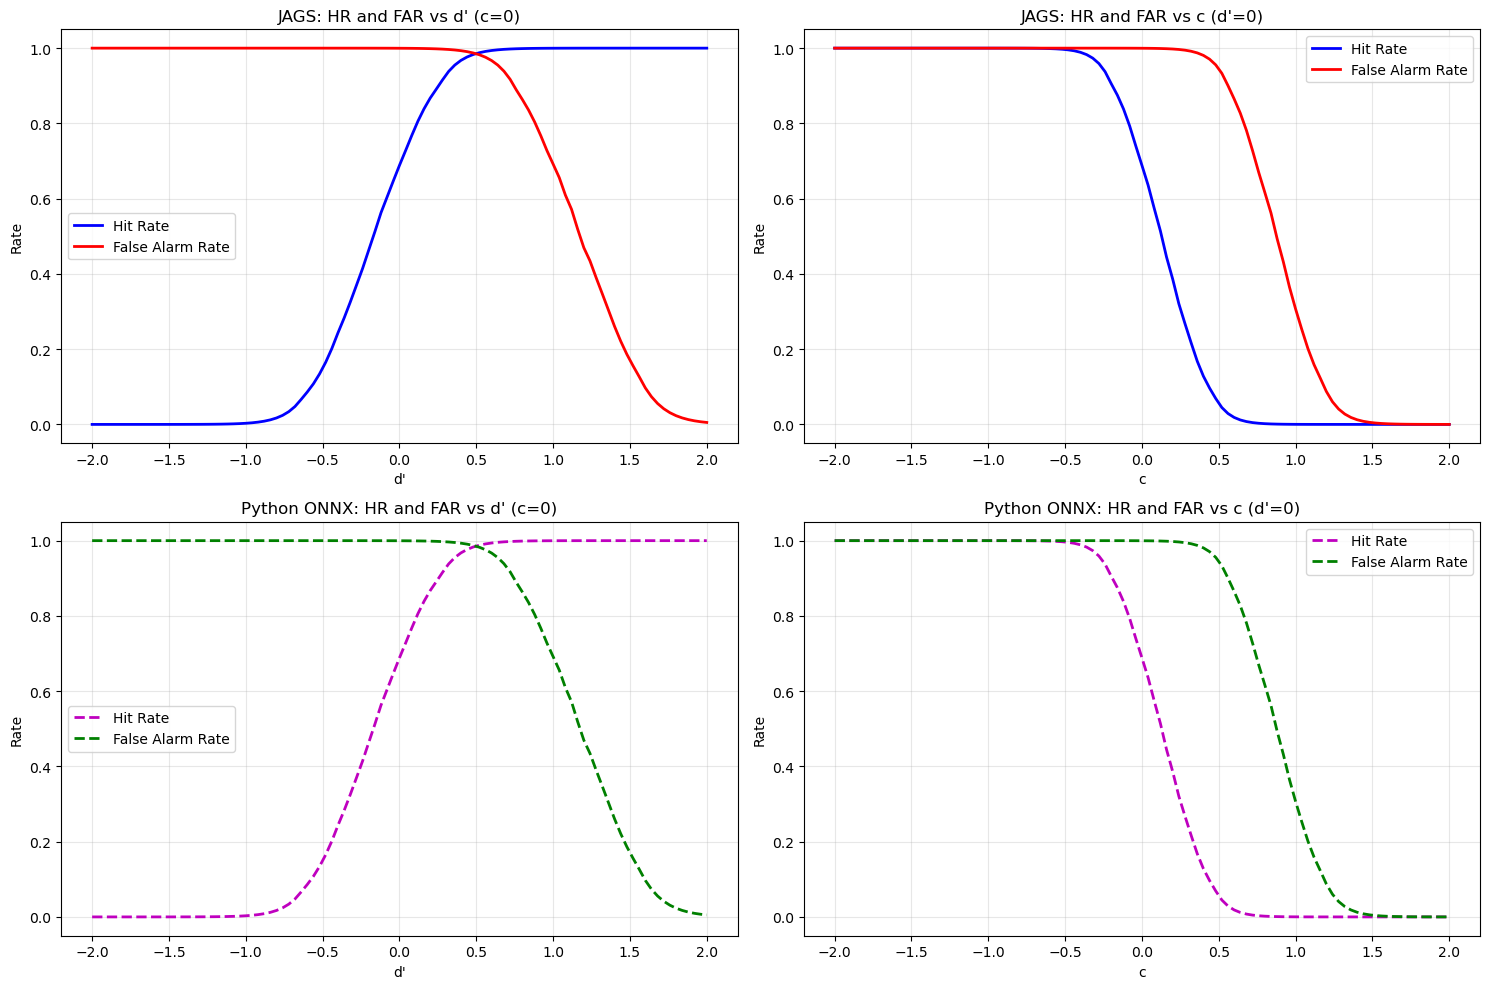

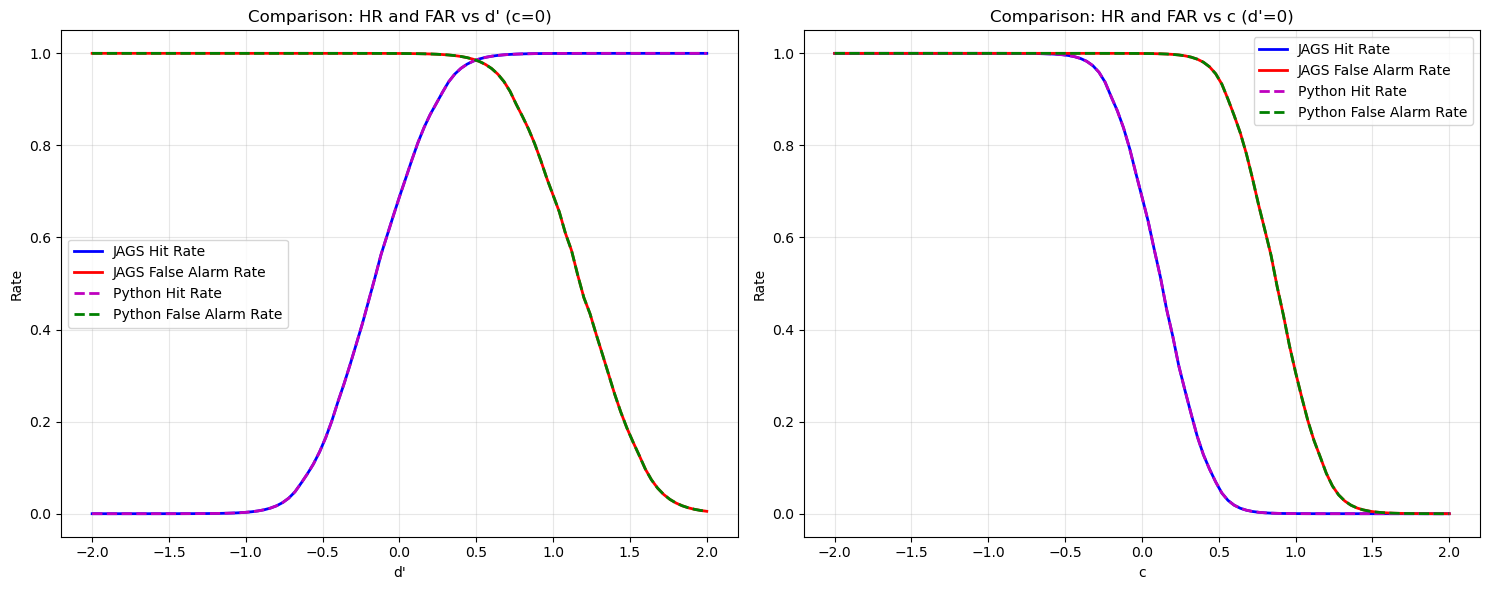


Maximum differences:
d' sweep - HR: 4.96e-07, FAR: 4.99e-07
c sweep - HR: 4.90e-07, FAR: 4.58e-07
SUCCESS: All results match within machine precision
Completed on  2025-10-29 20:03:16.082587


In [9]:
# Parameter Sweep Analysis
import py2jags
import onnxruntime as ort
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from jnnx import JNNXPackage

# Load the package and ONNX session
pkg = JNNXPackage('/home/jovyan/project/models/sdt.jnnx')
session = ort.InferenceSession(pkg.get_onnx_path())

# Define parameter ranges
d_prime_values = np.linspace(-2, 2, 101)
c_values = np.linspace(-2, 2, 101)

# Initialize arrays for results
jags_hr_dprime = np.zeros(101)
jags_far_dprime = np.zeros(101)
jags_hr_c = np.zeros(101)
jags_far_c = np.zeros(101)

python_hr_dprime = np.zeros(101)
python_far_dprime = np.zeros(101)
python_hr_c = np.zeros(101)
python_far_c = np.zeros(101)

print("Evaluating JAGS model...")

# JAGS evaluation: d' varies, c=0
for i, d_prime in enumerate(d_prime_values):
    model_string = f'''
    model {{
        result <- {FUNCTION_NAME}({d_prime}, 0.0)
        dummy ~ dnorm(0, 1)
    }}
    '''
    
    result = py2jags.run_jags(
        model_string=model_string,
        data_dict={'n': 1},
        nchains=1, nsamples=1, nadapt=0, nburnin=0,
        monitorparams=['result'],
        modules=[MODULE_NAME],
        verbosity=0
    )
    
    jags_hr_dprime[i] = result.get_samples('result_1')[0]
    jags_far_dprime[i] = result.get_samples('result_2')[0]

# JAGS evaluation: c varies, d'=0
for i, c in enumerate(c_values):
    model_string = f'''
    model {{
        result <- {FUNCTION_NAME}(0.0, {c})
        dummy ~ dnorm(0, 1)
    }}
    '''
    
    result = py2jags.run_jags(
        model_string=model_string,
        data_dict={'n': 1},
        nchains=1, nsamples=1, nadapt=0, nburnin=0,
        monitorparams=['result'],
        modules=[MODULE_NAME],
        verbosity=0
    )
    
    jags_hr_c[i] = result.get_samples('result_1')[0]
    jags_far_c[i] = result.get_samples('result_2')[0]

print("Evaluating Python ONNX model...")

# Python ONNX evaluation: d' varies, c=0
for i, d_prime in enumerate(d_prime_values):
    test_input = np.array([[d_prime, 0.0]], dtype=np.float32)
    result = session.run(['output'], {'input': test_input})
    python_hr_dprime[i] = result[0][0][0]
    python_far_dprime[i] = result[0][0][1]

# Python ONNX evaluation: c varies, d'=0
for i, c in enumerate(c_values):
    test_input = np.array([[0.0, c]], dtype=np.float32)
    result = session.run(['output'], {'input': test_input})
    python_hr_c[i] = result[0][0][0]
    python_far_c[i] = result[0][0][1]

print("Creating plots...")

# Create plots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: HR and FAR vs d' (JAGS)
axes[0, 0].plot(d_prime_values, jags_hr_dprime, 'b-', label='Hit Rate', linewidth=2)
axes[0, 0].plot(d_prime_values, jags_far_dprime, 'r-', label='False Alarm Rate', linewidth=2)
axes[0, 0].set_xlabel("d'")
axes[0, 0].set_ylabel("Rate")
axes[0, 0].set_title("JAGS: HR and FAR vs d' (c=0)")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: HR and FAR vs c (JAGS)
axes[0, 1].plot(c_values, jags_hr_c, 'b-', label='Hit Rate', linewidth=2)
axes[0, 1].plot(c_values, jags_far_c, 'r-', label='False Alarm Rate', linewidth=2)
axes[0, 1].set_xlabel("c")
axes[0, 1].set_ylabel("Rate")
axes[0, 1].set_title("JAGS: HR and FAR vs c (d'=0)")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: HR and FAR vs d' (Python)
axes[1, 0].plot(d_prime_values, python_hr_dprime, 'm--', label='Hit Rate', linewidth=2)
axes[1, 0].plot(d_prime_values, python_far_dprime, 'g--', label='False Alarm Rate', linewidth=2)
axes[1, 0].set_xlabel("d'")
axes[1, 0].set_ylabel("Rate")
axes[1, 0].set_title("Python ONNX: HR and FAR vs d' (c=0)")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: HR and FAR vs c (Python)
axes[1, 1].plot(c_values, python_hr_c, 'm--', label='Hit Rate', linewidth=2)
axes[1, 1].plot(c_values, python_far_c, 'g--', label='False Alarm Rate', linewidth=2)
axes[1, 1].set_xlabel("c")
axes[1, 1].set_ylabel("Rate")
axes[1, 1].set_title("Python ONNX: HR and FAR vs c (d'=0)")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Overlay comparison plots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Overlay d' plots
axes[0].plot(d_prime_values, jags_hr_dprime, 'b-', label='JAGS Hit Rate', linewidth=2)
axes[0].plot(d_prime_values, jags_far_dprime, 'r-', label='JAGS False Alarm Rate', linewidth=2)
axes[0].plot(d_prime_values, python_hr_dprime, 'm--', label='Python Hit Rate', linewidth=2)
axes[0].plot(d_prime_values, python_far_dprime, 'g--', label='Python False Alarm Rate', linewidth=2)
axes[0].set_xlabel("d'")
axes[0].set_ylabel("Rate")
axes[0].set_title("Comparison: HR and FAR vs d' (c=0)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Overlay c plots
axes[1].plot(c_values, jags_hr_c, 'b-', label='JAGS Hit Rate', linewidth=2)
axes[1].plot(c_values, jags_far_c, 'r-', label='JAGS False Alarm Rate', linewidth=2)
axes[1].plot(c_values, python_hr_c, 'm--', label='Python Hit Rate', linewidth=2)
axes[1].plot(c_values, python_far_c, 'g--', label='Python False Alarm Rate', linewidth=2)
axes[1].set_xlabel("c")
axes[1].set_ylabel("Rate")
axes[1].set_title("Comparison: HR and FAR vs c (d'=0)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate and display differences
max_diff_dprime_hr = np.max(np.abs(jags_hr_dprime - python_hr_dprime))
max_diff_dprime_far = np.max(np.abs(jags_far_dprime - python_far_dprime))
max_diff_c_hr = np.max(np.abs(jags_hr_c - python_hr_c))
max_diff_c_far = np.max(np.abs(jags_far_c - python_far_c))

print(f"\nMaximum differences:")
print(f"d' sweep - HR: {max_diff_dprime_hr:.2e}, FAR: {max_diff_dprime_far:.2e}")
print(f"c sweep - HR: {max_diff_c_hr:.2e}, FAR: {max_diff_c_far:.2e}")

if max(max_diff_dprime_hr, max_diff_dprime_far, max_diff_c_hr, max_diff_c_far) < 1e-6:
    print("SUCCESS: All results match within machine precision")
else:
    print("WARNING: Some differences exceed machine precision")

print("Completed on ", datetime.now())

## Expected Results

Both outputs should match within machine precision (differences < 1e-6). The SDT model outputs 2 values representing:

1. Hit rate
2. False alarm rate
